In [1]:
# ============================================================================
# 0. GEREKLİ KÜTÜPHANELERİN YÜKLENMESİ VE AYARLAR
# ============================================================================
import json
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings('ignore')

# Grafiklerin jüriye şık görünmesi için görsel ayarlar
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print("✅ Kütüphaneler ve görsel temalar başarıyla yüklendi!")

✅ Kütüphaneler ve görsel temalar başarıyla yüklendi!


In [ ]:
# ============================================================================
# 1. DOSYA YÜKLEME VE SENTETİK HATA ÜRETİMİ
# ============================================================================
print("⏳ Veriler yükleniyor, lütfen bekleyin...")
ast_verileri = []
with open("archive/py150/python100k_train.json", "r") as f:
    for i, satir in enumerate(f):
        if i >= 20000:  
            break
        ast_verileri.append(json.loads(satir))

df = pd.DataFrame({"ast_nodes": ast_verileri})
df["label"] = 0  # İlk yüklenenlerin hepsi hatasız temiz kodlar (Base)

def ast_boz(ast_liste):
    """AST listesini json formatında kopyalar ve rastgele bir düğümünü bozar."""
    bozuk_ast = json.loads(json.dumps(ast_liste))
    if len(bozuk_ast) > 2:
        secilen_index = random.randint(1, len(bozuk_ast) - 1)
        hata_turu = random.choice(["tip_degistir", "cocuk_sil", "deger_sil"])
        if hata_turu == "tip_degistir": 
            bozuk_ast[secilen_index]["type"] = "HataliDugum"
        elif hata_turu == "cocuk_sil":
            if "children" in bozuk_ast[secilen_index]: del bozuk_ast[secilen_index]["children"]
            else: bozuk_ast[secilen_index]["type"] = "HataliDugum" 
        elif hata_turu == "deger_sil":
            if "value" in bozuk_ast[secilen_index]: del bozuk_ast[secilen_index]["value"]
            else: bozuk_ast[secilen_index]["type"] = "HataliDugum"
    return bozuk_ast

# %50 veriyi rastgele seçip mutasyona uğratıyoruz
df_bozulacaklar = df.sample(frac=0.5, random_state=42).copy()
df_bozulacaklar["ast_nodes"] = df_bozulacaklar["ast_nodes"].apply(ast_boz)
df_bozulacaklar["label"] = 1  # Hatalı etiketli veriler

# Hatasız ve hatalı verileri birleştirip karıştırıyoruz
final_df = pd.concat([df, df_bozulacaklar], ignore_index=True)
df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n📋 [Sütun Analizi] Mevcut Sütunlar ve Yapısı:")
print(df.info())

⏳ Veriler yükleniyor, lütfen bekleyin...

📋 [Sütun Analizi] Mevcut Sütunlar ve Yapısı:
<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ast_nodes  7500 non-null   object
 1   label      7500 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 117.3+ KB
None


In [3]:
# ============================================================================
# 2. KOPYA SATIR KONTROLÜ VE VERİ ARINDIRMA
# ============================================================================
# AST listeleri doğrudan taranamayacağı için string'e çevirip kopyaları buluyoruz
df['ast_str_temp'] = df['ast_nodes'].astype(str)
kopya_sayisi = df.duplicated(subset=['ast_str_temp']).sum()
print(f"✨ [Kopya Analizi] Tespit edilen yinelenen satır sayısı: {kopya_sayisi}")

if kopya_sayisi > 0:
    df = df.drop_duplicates(subset=['ast_str_temp']).reset_index(drop=True)
    print("🚀 Kopya satırlar başarıyla temizlendi!")

# Geçici oluşturduğumuz string sütununu siliyoruz
df = df.drop(columns=['ast_str_temp'])

✨ [Kopya Analizi] Tespit edilen yinelenen satır sayısı: 30
🚀 Kopya satırlar başarıyla temizlendi!


📌 Güncel Sınıf Dağılım Sayıları:
label
0    4978
1    2492
Name: count, dtype: int64


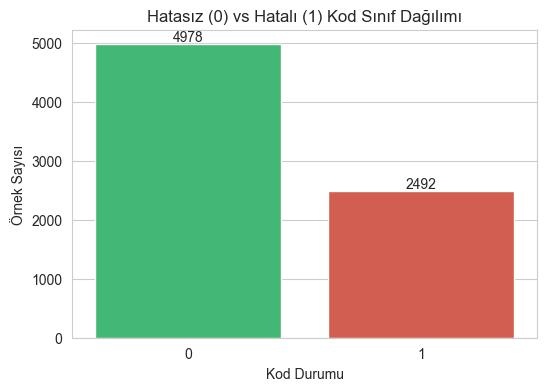

In [17]:
# ============================================================================
# 3. HEDEF DEĞİŞKEN (LABEL) SINIF DAĞILIMI
# ============================================================================
print("📌 Güncel Sınıf Dağılım Sayıları:")
print(df['label'].value_counts())

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='label', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title("Hatasız (0) vs Hatalı (1) Kod Sınıf Dağılımı")
plt.xlabel("Kod Durumu")
plt.ylabel("Örnek Sayısı")

# Çubukların üzerine net örnek sayılarını yazdıralım
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

📏 Düğüm Sayısı İstatistiksel Özeti:
        count    mean      std  min   25%    50%     75%      max
label                                                            
0      4978.0  572.87  1223.59  3.0  48.0  183.0  549.75  18292.0
1      2492.0  569.82  1217.04  1.0  49.0  188.0  553.00  18292.0


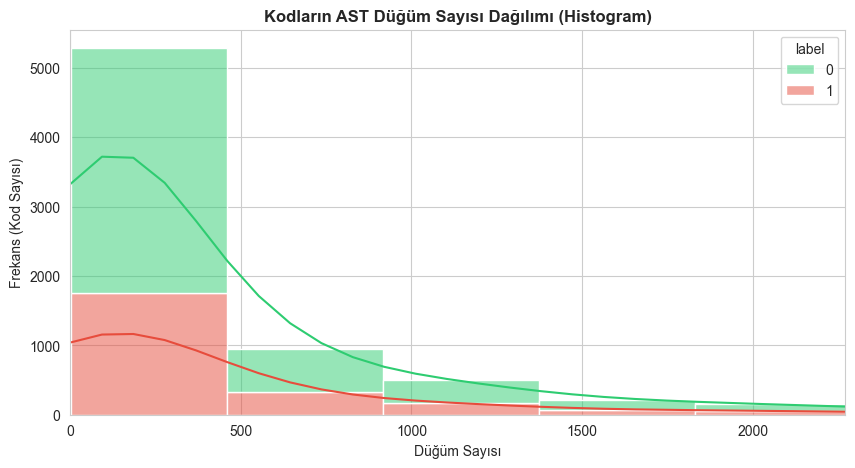

In [18]:
# ============================================================================
# 4. KOD KARMAŞIKLIĞI DAĞILIMI - HISTOGRAM
# ============================================================================
df['node_count'] = df['ast_nodes'].apply(len)

print("📏 Düğüm Sayısı İstatistiksel Özeti:")
print(df.groupby('label')['node_count'].describe().round(2))

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='node_count', hue='label', bins=40, kde=True, palette=['#2ecc71', '#e74c3c'], multiple='stack')
plt.title('Kodların AST Düğüm Sayısı Dağılımı (Histogram)', fontsize=12, fontweight='bold')
plt.xlabel('Düğüm Sayısı')
plt.ylabel('Frekans (Kod Sayısı)')
plt.xlim(0, df['node_count'].quantile(0.95))
plt.show()

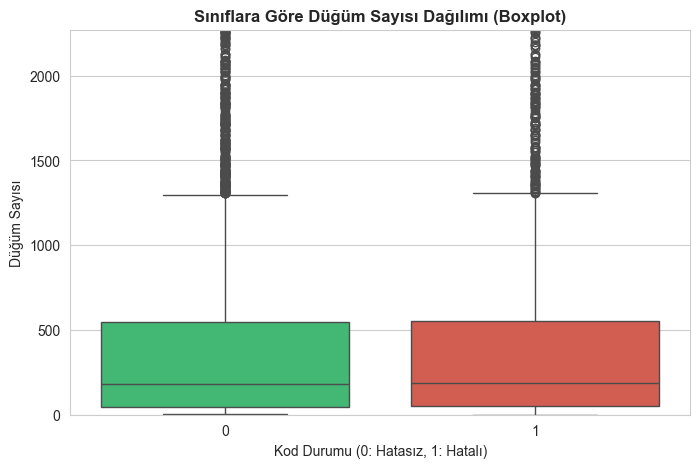

In [19]:
# ============================================================================
# 5. SINIFLARA GÖRE DÜĞÜM SAYISI DAĞILIMI - BOXPLOT
# ============================================================================
plt.figure(figsize=(8, 5))
sns.boxplot(x='label', y='node_count', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Sınıflara Göre Düğüm Sayısı Dağılımı (Boxplot)', fontsize=12, fontweight='bold')
plt.xlabel('Kod Durumu (0: Hatasız, 1: Hatalı)')
plt.ylabel('Düğüm Sayısı')
plt.ylim(0, df['node_count'].quantile(0.95))
plt.show()

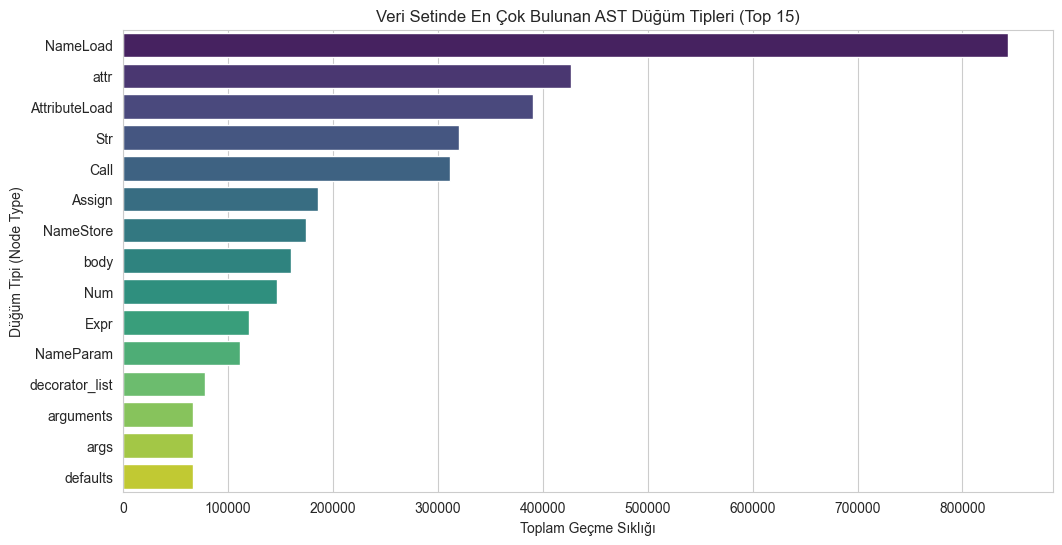

In [20]:
# ============================================================================
# 6. EN SIK GEÇEN AST DÜĞÜM TİPLERİ ANALİZİ
# ============================================================================
tum_tipler = []
for ast_liste in df['ast_nodes']:
    for dugum in ast_liste:
        tum_tipler.append(dugum.get("type", ""))

tip_frekanslari = pd.Series(tum_tipler).value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=tip_frekanslari.head(15).values, y=tip_frekanslari.head(15).index, palette='viridis')
plt.title('Veri Setinde En Çok Bulunan AST Düğüm Tipleri (Top 15)')
plt.xlabel('Toplam Geçme Sıklığı')
plt.ylabel('Düğüm Tipi (Node Type)')
plt.show()

🔍 1. Ham Veri Sütunlarında NaN Kontrolü:
ast_nodes     0
label         0
node_count    0
dtype: int64

🔍 2. Sayısal TF-IDF Özelliklerinde NaN Kontrolü:
Toplam NaN Sayısı: 0

🔍 3. Sayısal TF-IDF Özelliklerinde Sonsuzluk (Inf) Kontrolü:
Toplam Sonsuz (Inf) Değer Sayısı: 0

📊 Korelasyon Matrisi Isı Haritası Çiziliyor...


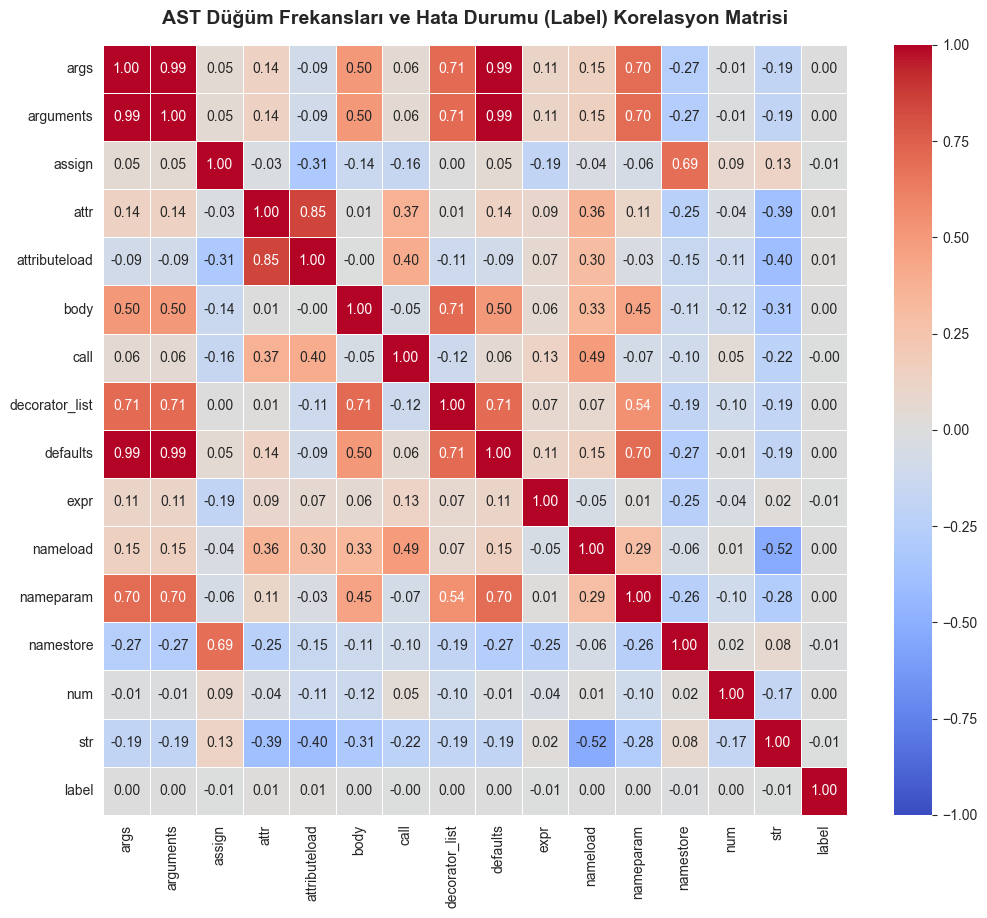


🎯 Hatayla En Güçlü Pozitif İlişkiye Sahip Düğümler:
label    1.0
Name: label, dtype: float64

🍏 Temiz Kod Yapılarında Daha Sık Görülen Düğümler:
Series([], Name: label, dtype: float64)


In [21]:
# ============================================================================
# 7. SIZINTISIZ KORELASYON ANALİZİ VE VALIDASYON
# ============================================================================
print("🔍 1. Ham Veri Sütunlarında NaN Kontrolü:")
print(df.isnull().sum())

# Düğümleri kelime metnine döküp istatistik matrisi çıkarıyoruz
df['clean_ast_text'] = df['ast_nodes'].apply(lambda x: " ".join([d.get("type", "") for d in x]))
vectorizer = TfidfVectorizer(max_features=15, lowercase=True) # En popüler 15 yapısal özellik
X_tfidf = vectorizer.fit_transform(df['clean_ast_text']).toarray()

features_df = pd.DataFrame(X_tfidf, columns=vectorizer.get_feature_names_out())
features_df['label'] = df['label']

print("\n🔍 2. Sayısal TF-IDF Özelliklerinde NaN Kontrolü:")
nan_count = features_df.isnull().sum().sum()
print(f"Toplam NaN Sayısı: {nan_count}")

print("\n🔍 3. Sayısal TF-IDF Özelliklerinde Sonsuzluk (Inf) Kontrolü:")
inf_count = np.isinf(features_df.iloc[:, :-1]).sum().sum()
print(f"Toplam Sonsuz (Inf) Değer Sayısı: {inf_count}")

# Olası gürültü temizliği (Koruma kalkanı)
if nan_count > 0: features_df = features_df.fillna(0)
if inf_count > 0: features_df = features_df.replace([np.inf, -np.inf], np.nan).fillna(0)

# Korelasyon matrisini hesaplama ve Isı Haritasını Çizdirme
print("\n📊 Korelasyon Matrisi Isı Haritası Çiziliyor...")
corr_matrix = features_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("AST Düğüm Frekansları ve Hata Durumu (Label) Korelasyon Matrisi", fontsize=14, fontweight='bold', pad=15)
plt.show()

# Korelasyon rapor özeti
target_corr = corr_matrix['label'].sort_values(ascending=False)
print("\n🎯 Hatayla En Güçlü Pozitif İlişkiye Sahip Düğümler:")
print(target_corr[target_corr > 0.05])

print("\n🍏 Temiz Kod Yapılarında Daha Sık Görülen Düğümler:")
print(target_corr[target_corr < -0.05])